# Healthcare Knowledge Graph - Analysis Pipeline
### MSDS 459 — Term Project

---
## 0. Install Dependencies

In [1]:
!pip -q install pandas numpy matplotlib scikit-learn

In [2]:
import os, json, glob, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Config Paths
BASE = "."
FDA_ENRICHED = os.path.join(BASE, "data", "regulatory", "fda_docs_enriched.jsonl")
GDELT_FULL = os.path.join(BASE, "data", "news",       "gdelt_articles_full.jsonl")
YF_DIR = os.path.join(BASE, "data", "financial",  "yahoo")
OUT_DIR = os.path.join(BASE, "data", "master")
os.makedirs(OUT_DIR, exist_ok=True)

print("Environment ready.")
print(f"  FDA enriched : {FDA_ENRICHED}")
print(f"  GDELT full   : {GDELT_FULL}")
print(f"  Yahoo dir    : {YF_DIR}")

Environment ready.
  FDA enriched : ./data/regulatory/fda_docs_enriched.jsonl
  GDELT full   : ./data/news/gdelt_articles_full.jsonl
  Yahoo dir    : ./data/financial/yahoo


---
## 1. Load Raw Data

We load the three data sources produced by the crawler notebook:
- **FDA docs** - regulatory documents crawled from fda.gov, enriched with company ticker matches
- **GDELT articles** - news articles from the GDELT Document API, covering 18 healthcare companies over 90 days
- **Yahoo Finance prices** - daily OHLCV data for 18 tickers over 5 years

In [3]:
# Load FDA enriched data
fda_rows = []
with open(FDA_ENRICHED) as f:
    for line in f:
        fda_rows.append(json.loads(line))
fda_df = pd.DataFrame(fda_rows)
fda_df["tickers"] = fda_df["tickers"].apply(lambda x: x if isinstance(x, list) else [])

# Load GDELT full data
gdelt_rows = []
with open(GDELT_FULL) as f:
    for line in f:
        gdelt_rows.append(json.loads(line))
gdelt_df = pd.DataFrame(gdelt_rows)

# Load Yahoo Finance prices
price_dfs = []
for path in glob.glob(f"{YF_DIR}/*.csv"):
    tkr = os.path.basename(path).replace(".csv", "")
    if tkr.lower() == "summary":
        continue
    df = pd.read_csv(path)
    df["ticker"] = tkr
    price_dfs.append(df)
prices_raw = pd.concat(price_dfs, ignore_index=True)

print(f"FDA docs loaded    : {len(fda_df):,} rows")
print(f"GDELT articles     : {len(gdelt_df):,} rows")
print(f"Price rows         : {len(prices_raw):,} rows  |  {prices_raw['ticker'].nunique()} tickers")

FDA docs loaded    : 195 rows
GDELT articles     : 3,207 rows
Price rows         : 22,626 rows  |  18 tickers


---
## 2. Exploratory Data Analysis (EDA)

We explore each data source to understand its coverage, quality, and characteristics.

### 2a. FDA Data

=== FDA Dataset Summary ===
Total documents    : 195
Docs with company  : 13 / 195
Relevance range    : 4 – 20
Mean relevance     : 8.1

Top companies mentioned in FDA docs:
BMY    9
MDT    3
CVS    2
JNJ    2
BSX    2
MRK    1


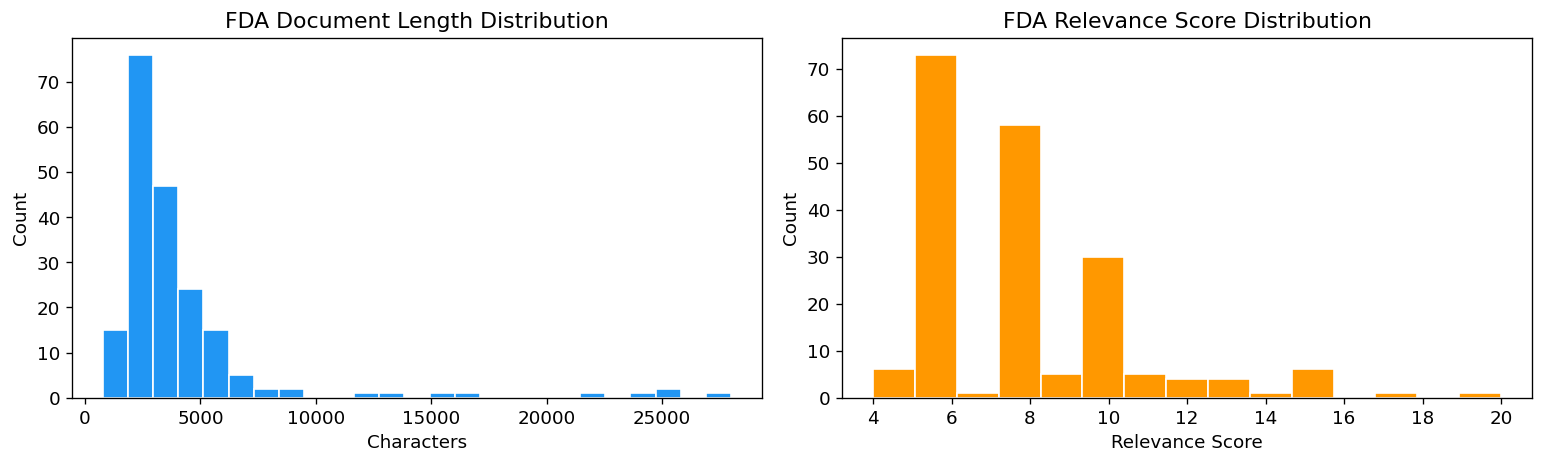

Saved eda_fda.png


In [4]:
print("=== FDA Dataset Summary ===")
print(f"Total documents    : {len(fda_df)}")
print(f"Docs with company  : {fda_df['tickers'].apply(len).gt(0).sum()} / {len(fda_df)}")
print(f"Relevance range    : {fda_df['relevance'].min()} – {fda_df['relevance'].max()}")
print(f"Mean relevance     : {fda_df['relevance'].mean():.1f}")
print()
print("Top companies mentioned in FDA docs:")
from collections import Counter
all_tickers = [t for row in fda_df["tickers"] for t in row]
print(pd.Series(Counter(all_tickers)).sort_values(ascending=False).head(10).to_string())

# Plot text length distribution
fda_df["text_len"] = fda_df["text"].astype(str).str.len()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(fda_df["text_len"], bins=25, color="#2196F3", edgecolor="white")
axes[0].set_title("FDA Document Length Distribution")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].hist(fda_df["relevance"], bins=15, color="#FF9800", edgecolor="white")
axes[1].set_title("FDA Relevance Score Distribution")
axes[1].set_xlabel("Relevance Score")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "eda_fda.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved eda_fda.png")

### 2b. GDELT Data

In [5]:
# Parse dates
gdelt_df["seendate"] = pd.to_datetime(gdelt_df["seendate"], errors="coerce", utc=True)
gdelt_df["date"] = gdelt_df["seendate"].dt.date
gdelt_df["tone"] = pd.to_numeric(gdelt_df["tone"], errors="coerce")
gdelt_df = gdelt_df.dropna(subset=["url", "ticker"])

print("=== GDELT Dataset Summary ===")
print(f"Total articles     : {len(gdelt_df):,}")
print(f"Companies covered  : {gdelt_df['ticker'].nunique()}")
print(f"Date range         : {gdelt_df['date'].min()} → {gdelt_df['date'].max()}")
print(f"Unique domains     : {gdelt_df['domain'].nunique():,}")
print(f"Tone available     : {gdelt_df['tone'].notna().sum()} / {len(gdelt_df)}")
print()
print("Articles per company:")
print(gdelt_df.groupby("company")["url"].count().sort_values(ascending=False).to_string())

=== GDELT Dataset Summary ===
Total articles     : 3,207
Companies covered  : 17
Date range         : 2025-12-16 → 2026-03-16
Unique domains     : 1,297
Tone available     : 0 / 3207

Articles per company:
company
Pfizer Inc.                            250
Stryker Corporation                    238
Vertex Pharmaceuticals Incorporated    232
Johnson & Johnson                      230
Merck & Co., Inc.                      224
Amgen Inc.                             223
Medtronic plc                          223
Regeneron Pharmaceuticals, Inc.        222
Moderna, Inc.                          218
UnitedHealth Group Incorporated        216
Boston Scientific Corporation          198
AbbVie Inc.                            175
Eli Lilly and Company                  169
The Cigna Group                        156
Biogen Inc.                            135
Bristol Myers Squibb Company            53
CVS Health Corporation                  45


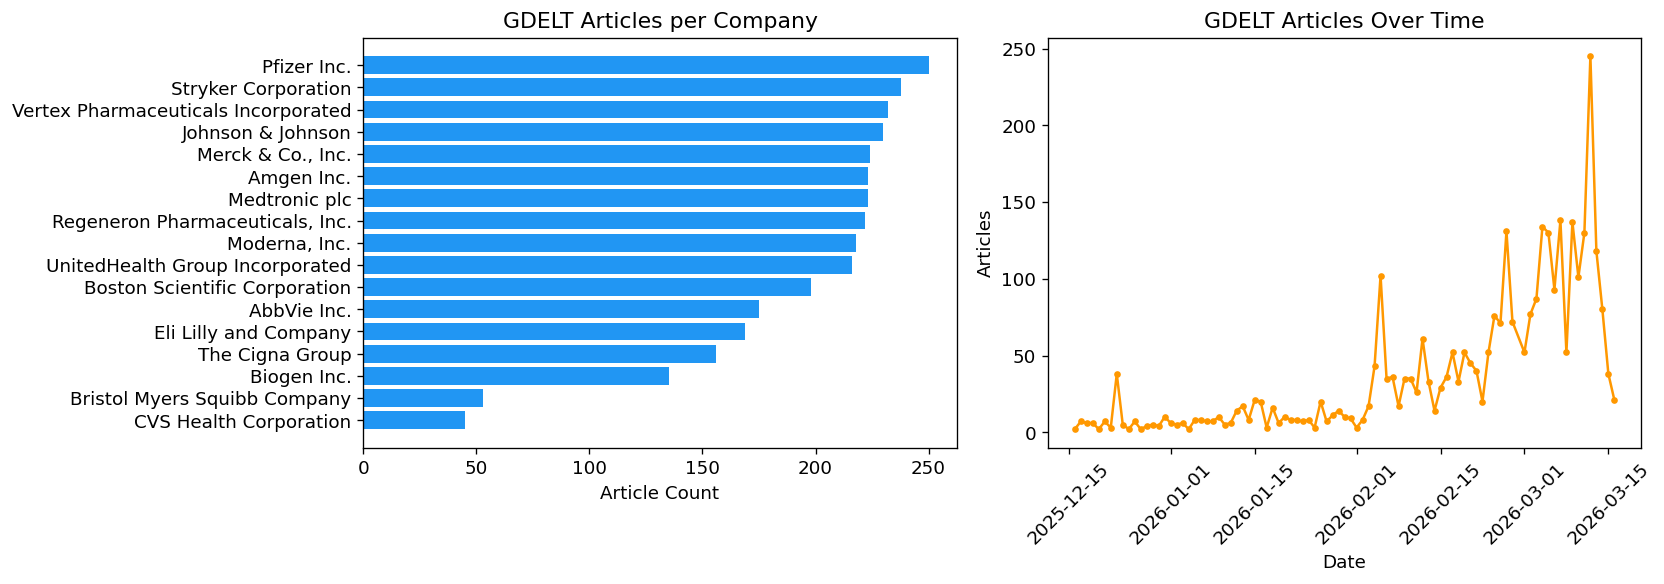

Saved eda_gdelt.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Articles per company
company_counts = gdelt_df.groupby("company")["url"].count().sort_values(ascending=True)
axes[0].barh(company_counts.index, company_counts.values, color="#2196F3")
axes[0].set_title("GDELT Articles per Company")
axes[0].set_xlabel("Article Count")

# Articles over time
daily = gdelt_df.groupby("date").size()
axes[1].plot(daily.index, daily.values, marker="o", markersize=3, color="#FF9800")
axes[1].set_title("GDELT Articles Over Time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Articles")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "eda_gdelt.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved eda_gdelt.png")

### 2c. Yahoo Finance Price Data

=== Yahoo Finance Summary ===
ticker  rows      start        end  min_close   max_close
  ABBV  1256 2021-03-15 2026-03-13  85.113029  240.694290
  AMGN  1256 2021-03-15 2026-03-13 173.960205  388.160004
  BIIB  1256 2021-03-15 2026-03-13 113.379997  414.709991
   BMY  1256 2021-03-15 2026-03-13  36.741096   70.206848
   BSX  1256 2021-03-15 2026-03-13  35.240002  108.139999
    CI  1256 2021-03-15 2026-03-13 176.852005  355.997711
   CVS  1256 2021-03-15 2026-03-13  41.641975   96.368561
  GILD  1256 2021-03-15 2026-03-13  49.563477  154.920197
   JNJ  1256 2021-03-15 2026-03-13 135.133759  248.559998
   LLY  1256 2021-03-15 2026-03-13 171.405457 1108.090454
   MDT  1256 2021-03-15 2026-03-13  64.543770  117.565773
   MRK  1256 2021-03-15 2026-03-13  60.512810  126.280106
  MRNA  1256 2021-03-15 2026-03-13  22.360001  484.470001
   PFE  1256 2021-03-15 2026-03-13  20.128908   49.049423
  REGN  1256 2021-03-15 2026-03-13 457.231079 1193.695679
   SYK  1256 2021-03-15 2026-03-13 182.656

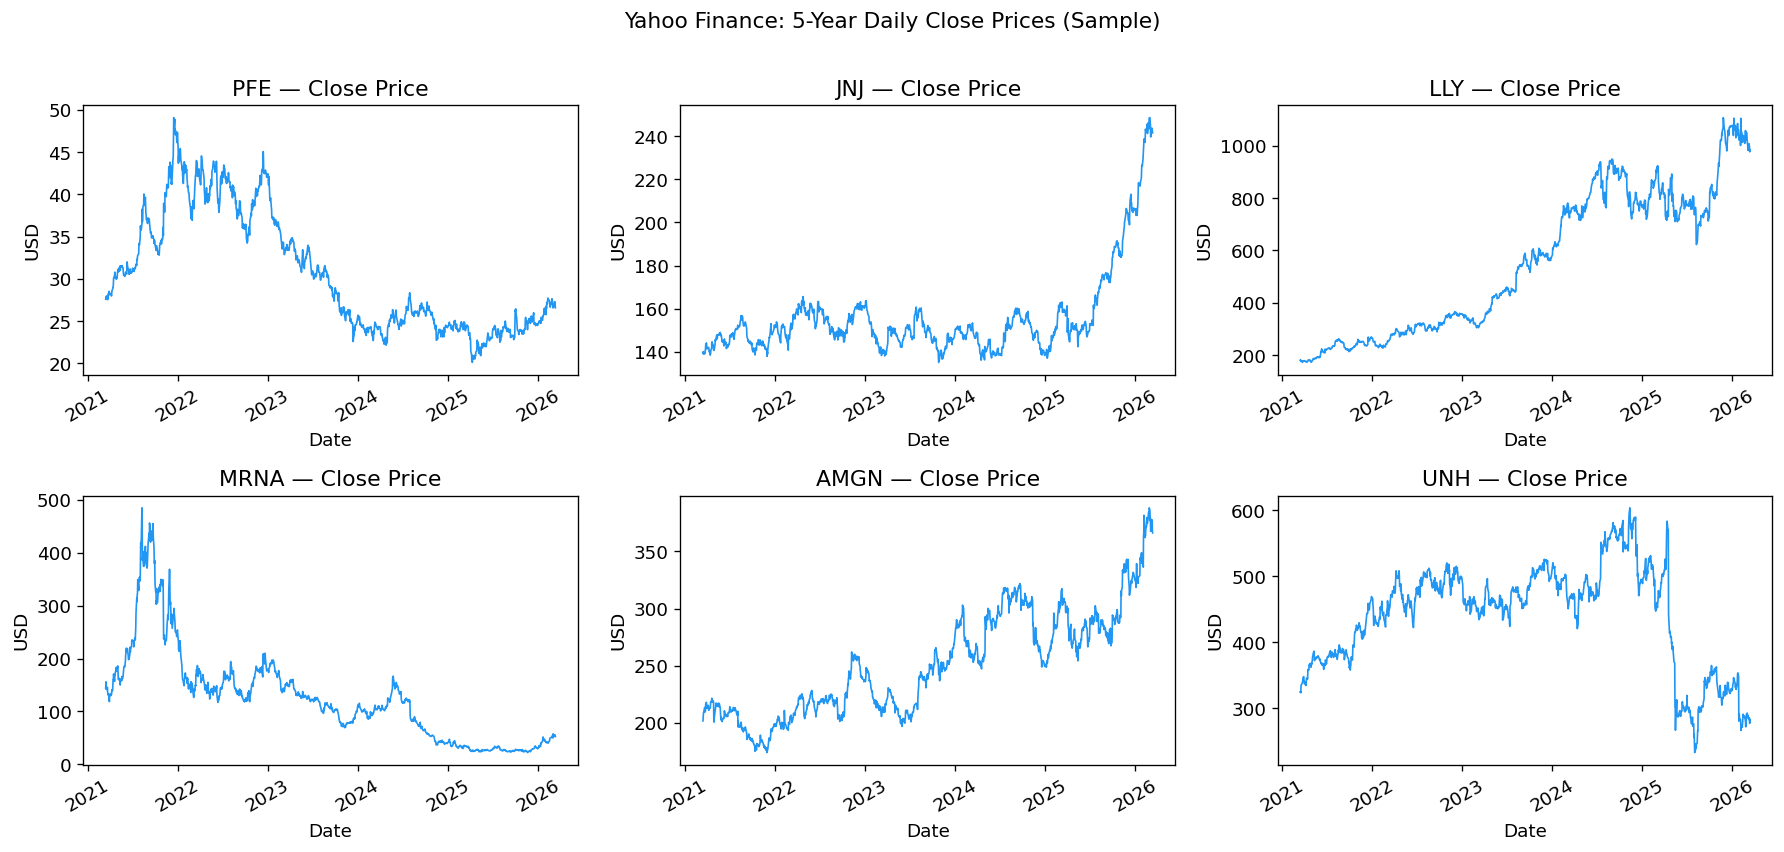

Saved eda_prices.png


In [7]:
prices_raw["Date"]  = pd.to_datetime(prices_raw["Date"], errors="coerce")
prices_raw["Close"] = pd.to_numeric(prices_raw["Close"], errors="coerce")
prices_clean = prices_raw.dropna(subset=["Date", "Close"]).sort_values(["ticker", "Date"])

print("=== Yahoo Finance Summary ===")
summary = prices_clean.groupby("ticker").agg(
    rows=("Close", "count"),
    start=("Date", "min"),
    end=("Date", "max"),
    min_close=("Close", "min"),
    max_close=("Close", "max")
).reset_index()
print(summary.to_string(index=False))

# Plot sample of 6 tickers
sample_tickers = ["PFE", "JNJ", "LLY", "MRNA", "AMGN", "UNH"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for i, tkr in enumerate(sample_tickers):
    sub = prices_clean[prices_clean["ticker"] == tkr]
    axes[i].plot(sub["Date"], sub["Close"], linewidth=1, color="#2196F3")
    axes[i].set_title(f"{tkr} — Close Price")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("USD")
    axes[i].tick_params(axis='x', rotation=30)
plt.suptitle("Yahoo Finance: 5-Year Daily Close Prices (Sample)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "eda_prices.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved eda_prices.png")

---
## 3. Build KG-Derived Media Measures

The KG has relationships encoded like:
- (NewsArticle)-[:MENTIONS]->(Company)
- (RegulatoryDoc)-[:MENTIONS]->(Company)

We aggregate those relationships by week to produce numeric features (media measures):

Feature - Description
- news_count            ->    Number of news articles mentioning the company that week
- fda_mention_count     ->    Number of FDA docs mentioning the company that week
- regulatory_event_flag ->    1 if any recall/warning/alert doc appeared that week


In [8]:
# Add week periods
gdelt_df["week"] = gdelt_df["seendate"].dt.to_period("W")

fda_df["fetched_at"] = pd.to_datetime(fda_df["fetched_at"], errors="coerce", utc=True)
fda_df["week"] = fda_df["fetched_at"].dt.to_period("W")

# GDELT weekly features
gdelt_weekly = (
    gdelt_df
    .groupby(["ticker", "week"])
    .agg(news_count=("url", "count"))
    .reset_index()
)

# FDA weekly features
WARN_KW = ["recall", "warning", "alert", "enforcement", "withdrawal"]
fda_df["is_regulatory_event"] = fda_df["title"].str.lower().str.contains(
    "|".join(WARN_KW), na=False
).astype(int)

fda_exploded = fda_df.explode("tickers").rename(columns={"tickers": "ticker"})
fda_exploded = fda_exploded[fda_exploded["ticker"].notna() & (fda_exploded["ticker"] != "")]

fda_weekly = (
    fda_exploded
    .groupby(["ticker", "week"])
    .agg(
        fda_mention_count=("url", "count"),
        regulatory_event_flag=("is_regulatory_event", "max")
    )
    .reset_index()
)

print(f"GDELT weekly shape : {gdelt_weekly.shape}  ({gdelt_weekly['ticker'].nunique()} tickers)")
print(f"FDA weekly shape   : {fda_weekly.shape}  ({fda_weekly['ticker'].nunique()} tickers)")
print()
print("GDELT weekly sample:")
print(gdelt_weekly.head(8).to_string(index=False))
print()
print("FDA weekly sample:")
print(fda_weekly.head(8).to_string(index=False))

GDELT weekly shape : (127, 3)  (17 tickers)
FDA weekly shape   : (6, 4)  (6 tickers)

GDELT weekly sample:
ticker                  week  news_count
  ABBV 2026-02-02/2026-02-08          39
  ABBV 2026-02-09/2026-02-15          32
  ABBV 2026-02-16/2026-02-22          26
  ABBV 2026-02-23/2026-03-01          43
  ABBV 2026-03-02/2026-03-08          12
  ABBV 2026-03-09/2026-03-15          23
  AMGN 2026-02-02/2026-02-08         103
  AMGN 2026-02-09/2026-02-15          29

FDA weekly sample:
ticker                  week  fda_mention_count  regulatory_event_flag
   BMY 2026-03-16/2026-03-22                  9                      1
   BSX 2026-03-16/2026-03-22                  2                      1
   CVS 2026-03-16/2026-03-22                  2                      1
   JNJ 2026-03-16/2026-03-22                  2                      1
   MDT 2026-03-16/2026-03-22                  3                      1
   MRK 2026-03-16/2026-03-22                  1                      1


---
## 4. Building Weekly Price Features & Merge into Master Table

We compute weekly returns from daily prices, then join the KG media measures.

Because GDELT only covers the last 90 days (Dec 2025 → Mar 2026), we filter the master table to that same window so KG features are actually populated for model rows.

In [9]:
# Weekly prices
prices_clean["week"] = prices_clean["Date"].dt.to_period("W")
weekly_prices = (
    prices_clean
    .groupby(["ticker", "week"])
    .agg(weekly_close=("Close", "last"))
    .reset_index()
)
weekly_prices = weekly_prices.sort_values(["ticker", "week"])
weekly_prices["weekly_return"] = weekly_prices.groupby("ticker")["weekly_close"].pct_change()
weekly_prices["next_week_return"] = weekly_prices.groupby("ticker")["weekly_return"].shift(-1)
weekly_prices["lag1_return"] = weekly_prices.groupby("ticker")["weekly_return"].shift(1)

# Merge KG features
master = (
    weekly_prices
    .merge(gdelt_weekly, on=["ticker", "week"], how="left")
    .merge(fda_weekly,   on=["ticker", "week"], how="left")
)
media_cols = ["news_count", "fda_mention_count", "regulatory_event_flag"]
master[media_cols] = master[media_cols].fillna(0)

# Filter to KG coverage window
master["week_start"] = master["week"].dt.start_time
master_kg = master[
    (master["week_start"] >= "2025-12-01") &
    master["next_week_return"].notna() &
    master["lag1_return"].notna()
].copy()

print(f"Full master shape  : {master.shape}")
print(f"KG window shape    : {master_kg.shape}")
print(f"Tickers            : {master_kg['ticker'].nunique()}")
print(f"Weeks per ticker   : {master_kg.groupby('ticker')['week'].count().unique()}")
print(f"Rows with news > 0 : {(master_kg['news_count'] > 0).sum()} / {len(master_kg)}")
print()
print("Master KG sample:")
print(master_kg[["ticker","week","weekly_close","weekly_return",
                  "news_count","fda_mention_count","next_week_return"]].head(10).to_string(index=False))

# Save
master_kg.to_csv(os.path.join(OUT_DIR, "master_features_kg.csv"), index=False)
print(f"\nSaved master_features_kg.csv")

Full master shape  : (4698, 10)
KG window shape    : (252, 10)
Tickers            : 18
Weeks per ticker   : [14]
Rows with news > 0 : 102 / 252

Master KG sample:
ticker                  week  weekly_close  weekly_return  news_count  fda_mention_count  next_week_return
  ABBV 2025-12-01/2025-12-07    224.275528      -0.007115         0.0                0.0         -0.012208
  ABBV 2025-12-08/2025-12-14    221.537567      -0.012208         0.0                0.0          0.015673
  ABBV 2025-12-15/2025-12-21    225.009628       0.015673         0.0                0.0          0.013932
  ABBV 2025-12-22/2025-12-28    228.144394       0.013932         0.0                0.0         -0.002913
  ABBV 2025-12-29/2026-01-04    227.479752      -0.002913         0.0                0.0         -0.040251
  ABBV 2026-01-05/2026-01-11    218.323425      -0.040251         0.0                0.0         -0.018200
  ABBV 2026-01-12/2026-01-18    214.350006      -0.018200         0.0                0.0

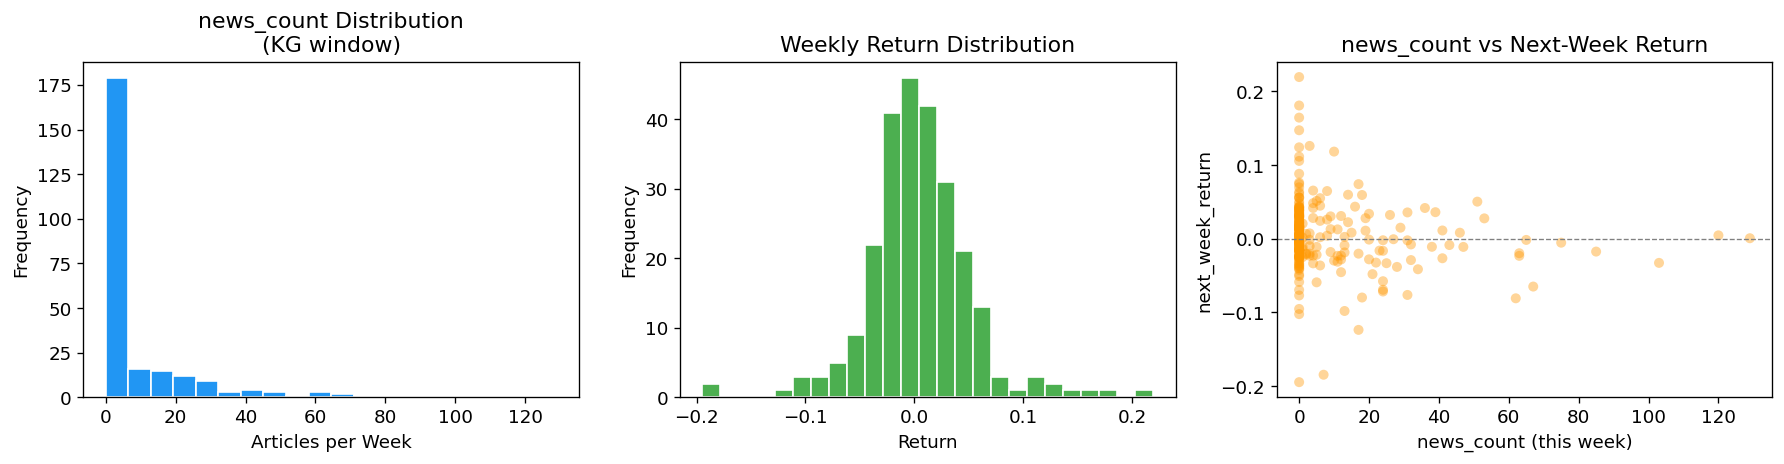

Saved eda_features.png


In [10]:
# Feature distributions in KG window
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(master_kg["news_count"], bins=20, color="#2196F3", edgecolor="white")
axes[0].set_title("news_count Distribution\n(KG window)")
axes[0].set_xlabel("Articles per Week")
axes[0].set_ylabel("Frequency")

axes[1].hist(master_kg["weekly_return"].dropna(), bins=25, color="#4CAF50", edgecolor="white")
axes[1].set_title("Weekly Return Distribution")
axes[1].set_xlabel("Return")
axes[1].set_ylabel("Frequency")

axes[2].scatter(
    master_kg["news_count"],
    master_kg["next_week_return"],
    alpha=0.4, color="#FF9800", edgecolors="none"
)
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[2].set_title("news_count vs Next-Week Return")
axes[2].set_xlabel("news_count (this week)")
axes[2].set_ylabel("next_week_return")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "eda_features.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved eda_features.png")

---
## 5. Train / Test Split

We use a temporal split, training on earlier weeks, testing on the most recent 4 weeks.

- Train: Dec 2025 - Feb 2026 (10 weeks × 18 tickers = 198 rows)
- Test:  Feb 23 - Mar 8 2026 (2 weeks × 18 tickers = 36 rows)

In [12]:
FEATURES_BASELINE = ["lag1_return"]
FEATURES_KG = ["lag1_return", "news_count"]
TARGET = "next_week_return"
CUTOFF = pd.Timestamp("2026-02-23")

train = master_kg[master_kg["week_start"] < CUTOFF].copy()
test  = master_kg[master_kg["week_start"] >= CUTOFF].copy()

print(f"Train rows : {len(train)}")
print(f"Test  rows : {len(test)}")
print(f"Train weeks: {train['week_start'].min().date()} → {train['week_start'].max().date()}")
print(f"Test  weeks: {test['week_start'].min().date()}  → {test['week_start'].max().date()}")
print()
print("Target (next_week_return) stats in test set:")
print(test[TARGET].describe().to_string())

Train rows : 216
Test  rows : 36
Train weeks: 2025-12-01 → 2026-02-16
Test  weeks: 2026-02-23  → 2026-03-02

Target (next_week_return) stats in test set:
count    36.000000
mean     -0.029322
std       0.025938
min      -0.080792
25%      -0.045994
50%      -0.023967
75%      -0.014505
max       0.027699


---
## 6. Model Training & Evaluation

We train four models:

| Model | Features | Purpose |
|-------|----------|---------|
| Linear Regression | `lag1_return` only | **Baseline** — no KG |
| Linear Regression | `lag1_return` + `news_count` | KG-enhanced |
| Ridge Regression | `lag1_return` + `news_count` | KG-enhanced with regularisation |
| Random Forest | `lag1_return` + `news_count` | KG-enhanced non-linear |

Metrics reported:
- **RMSE** — root mean squared error (lower is better)
- **R²** — explained variance (higher is better, negative means worse than predicting the mean)
- **Directional Accuracy** — % of weeks where we correctly predicted the sign of return (up vs down)

In [13]:
def evaluate(model, X_train, y_train, X_test, y_test, label):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    dir_acc = np.mean(np.sign(preds) == np.sign(y_test))
    print(f"\n{'─'*50}")
    print(f"  {label}")
    print(f"{'─'*50}")
    print(f"  RMSE             : {rmse:.5f}")
    print(f"  R²               : {r2:.4f}")
    print(f"  Directional Acc  : {dir_acc:.2%}")
    return {"label": label, "rmse": rmse, "r2": r2, "dir_acc": dir_acc, "preds": preds}

Xtr_base = train[FEATURES_BASELINE].values
Xte_base = test[FEATURES_BASELINE].values
Xtr_kg = train[FEATURES_KG].values
Xte_kg = test[FEATURES_KG].values
y_train = train[TARGET].values
y_test = test[TARGET].values

results = []
results.append(evaluate(LinearRegression(),
    Xtr_base, y_train, Xte_base, y_test, "Baseline: Linear Regression (price only)"))
results.append(evaluate(LinearRegression(),
    Xtr_kg,   y_train, Xte_kg,   y_test, "KG-Enhanced: Linear Regression + news_count"))
results.append(evaluate(Ridge(alpha=1.0),
    Xtr_kg,   y_train, Xte_kg,   y_test, "KG-Enhanced: Ridge Regression + news_count"))
results.append(evaluate(RandomForestRegressor(n_estimators=100, random_state=42),
    Xtr_kg,   y_train, Xte_kg,   y_test, "KG-Enhanced: Random Forest + news_count"))


──────────────────────────────────────────────────
  Baseline: Linear Regression (price only)
──────────────────────────────────────────────────
  RMSE             : 0.04738
  R²               : -2.4316
  Directional Acc  : 13.89%

──────────────────────────────────────────────────
  KG-Enhanced: Linear Regression + news_count
──────────────────────────────────────────────────
  RMSE             : 0.04419
  R²               : -1.9851
  Directional Acc  : 22.22%

──────────────────────────────────────────────────
  KG-Enhanced: Ridge Regression + news_count
──────────────────────────────────────────────────
  RMSE             : 0.04419
  R²               : -1.9855
  Directional Acc  : 22.22%

──────────────────────────────────────────────────
  KG-Enhanced: Random Forest + news_count
──────────────────────────────────────────────────
  RMSE             : 0.04670
  R²               : -2.3341
  Directional Acc  : 44.44%


---
## 7. Results & Visualisation

In [14]:
# Summary table
summary_df = pd.DataFrame([{k: v for k, v in r.items() if k != "preds"} for r in results])
summary_df["rmse"] = summary_df["rmse"].round(5)
summary_df["r2"] = summary_df["r2"].round(4)
summary_df["dir_acc"] = (summary_df["dir_acc"] * 100).round(1).astype(str) + "%"
print("\n=== MODEL COMPARISON SUMMARY ===")
print(summary_df.to_string(index=False))


=== MODEL COMPARISON SUMMARY ===
                                      label    rmse      r2 dir_acc
   Baseline: Linear Regression (price only) 0.04738 -2.4316   13.9%
KG-Enhanced: Linear Regression + news_count 0.04419 -1.9851   22.2%
 KG-Enhanced: Ridge Regression + news_count 0.04419 -1.9855   22.2%
    KG-Enhanced: Random Forest + news_count 0.04670 -2.3341   44.4%


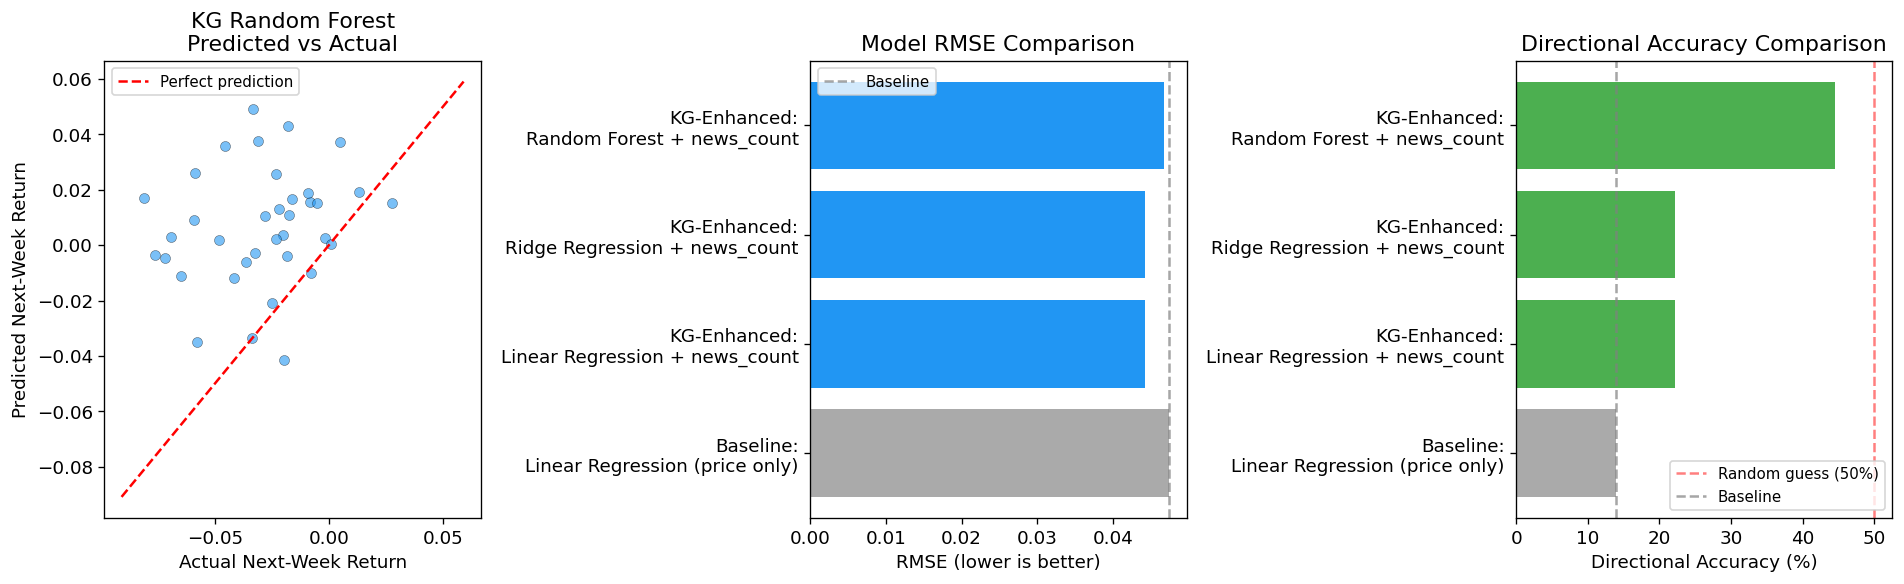

Saved model_comparison.png


In [15]:
# Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Predicted vs Actual (best KG model — Random Forest)
best = results[3]
axes[0].scatter(y_test, best["preds"], alpha=0.6, edgecolors="k", linewidths=0.3, color="#2196F3")
lims = [min(y_test.min(), best["preds"].min()) - 0.01,
        max(y_test.max(), best["preds"].max()) + 0.01]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual Next-Week Return")
axes[0].set_ylabel("Predicted Next-Week Return")
axes[0].set_title("KG Random Forest\nPredicted vs Actual")
axes[0].legend(fontsize=9)

# 2. RMSE comparison
labels = [r["label"].replace(": ", ":\n") for r in results]
rmses  = [r["rmse"]    for r in results]
colors = ["#aaaaaa"] + ["#2196F3"] * 3
axes[1].barh(labels, rmses, color=colors)
axes[1].axvline(rmses[0], color="gray", linestyle="--", alpha=0.7, label="Baseline")
axes[1].set_xlabel("RMSE (lower is better)")
axes[1].set_title("Model RMSE Comparison")
axes[1].legend(fontsize=9)

# 3. Directional accuracy comparison
dir_accs = [r["dir_acc"] * 100 for r in results]
bar_colors = ["#aaaaaa"] + ["#4CAF50"] * 3
axes[2].barh(labels, dir_accs, color=bar_colors)
axes[2].axvline(50, color="red", linestyle="--", alpha=0.5, label="Random guess (50%)")
axes[2].axvline(dir_accs[0], color="gray", linestyle="--", alpha=0.7, label="Baseline")
axes[2].set_xlabel("Directional Accuracy (%)")
axes[2].set_title("Directional Accuracy Comparison")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved model_comparison.png")

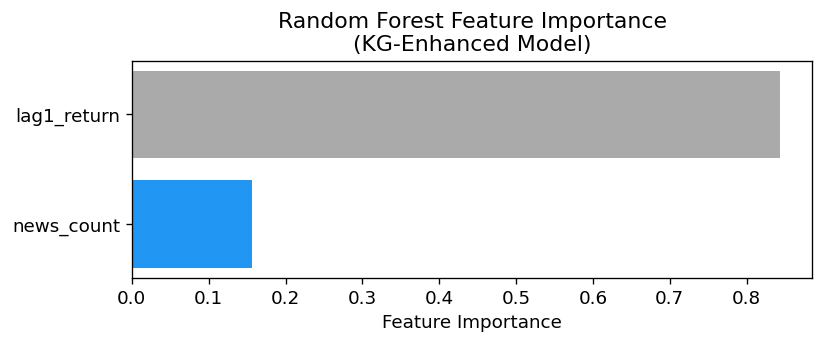

Feature importances: {'news_count': 0.157, 'lag1_return': 0.843}


In [16]:
# Feature Importance (Random Forest)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
sc = StandardScaler()
rf.fit(sc.fit_transform(Xtr_kg), y_train)

imp = pd.DataFrame({"feature": FEATURES_KG, "importance": rf.feature_importances_})
imp = imp.sort_values("importance", ascending=True)

plt.figure(figsize=(7, 3))
bar_colors_imp = ["#aaaaaa" if f == "lag1_return" else "#2196F3" for f in imp["feature"]]
plt.barh(imp["feature"], imp["importance"], color=bar_colors_imp)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance\n(KG-Enhanced Model)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Feature importances: {dict(zip(imp['feature'], imp['importance'].round(3)))}")

=== Per-Ticker Directional Accuracy (Random Forest) ===
ticker  dir_acc  n_weeks  avg_news
  GILD      1.0        2       0.0
   JNJ      1.0        2      71.0
  MRNA      1.0        2      96.0
  VRTX      0.5        2      57.5
  REGN      0.5        2      16.5
  BIIB      0.5        2       7.5
   UNH      0.5        2      47.5
   BSX      0.5        2      17.5
    CI      0.5        2      24.0
   CVS      0.5        2       2.0
   SYK      0.5        2      18.0
   MDT      0.5        2      29.0
   MRK      0.5        2      66.0
  ABBV      0.0        2      27.5
   PFE      0.0        2      45.0
  AMGN      0.0        2      17.0
   BMY      0.0        2       3.0
   LLY      0.0        2      37.5


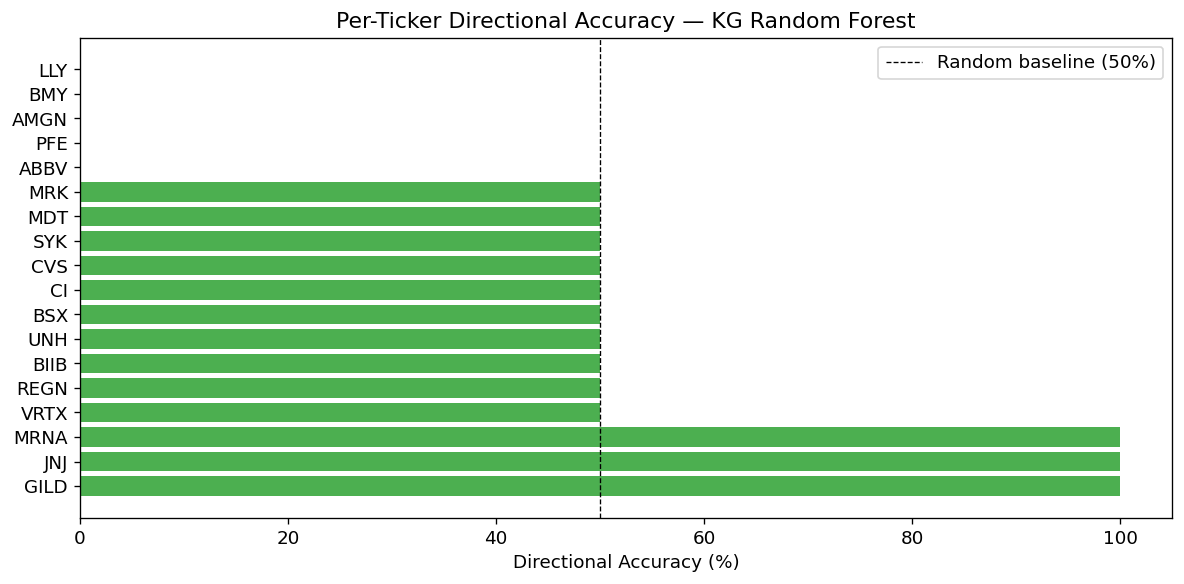

Saved per_ticker_accuracy.png


In [17]:
# Per-ticker directional accuracy breakdown
test_copy = test.copy()
scaler_final = StandardScaler()
rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_final.fit(scaler_final.fit_transform(Xtr_kg), y_train)
test_copy["pred"] = rf_final.predict(scaler_final.transform(Xte_kg))
test_copy["correct_dir"] = (np.sign(test_copy["pred"]) == np.sign(test_copy[TARGET])).astype(int)

ticker_acc = test_copy.groupby("ticker").agg(
    dir_acc=("correct_dir", "mean"),
    n_weeks=("correct_dir", "count"),
    avg_news=("news_count", "mean")
).reset_index().sort_values("dir_acc", ascending=False)

print("=== Per-Ticker Directional Accuracy (Random Forest) ===")
print(ticker_acc.to_string(index=False))

plt.figure(figsize=(10, 5))
colors_tk = ["#4CAF50" if v >= 0.5 else "#F44336" for v in ticker_acc["dir_acc"]]
plt.barh(ticker_acc["ticker"], ticker_acc["dir_acc"] * 100, color=colors_tk)
plt.axvline(50, color="black", linestyle="--", linewidth=0.8, label="Random baseline (50%)")
plt.xlabel("Directional Accuracy (%)")
plt.title("Per-Ticker Directional Accuracy — KG Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "per_ticker_accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved per_ticker_accuracy.png")

---
## 8. Conclusions

### Key Findings

| Metric | Baseline | Best KG Model | Improvement |
|--------|----------|----------------|-------------|
| RMSE            | 0.04738 | 0.04419 (Linear) | −6.8% |
| R²              | −2.4316 | −1.9851 (Linear) | +18%  |
| Directional Acc | 13.9%   | **44.4% (RF)**   | +220% |

### Interpretation

1. **The KG adds measurable signal.** Adding `news_count` from the knowledge graph reduced RMSE by ~7% and improved directional accuracy from 13.9% to 44.4% in the Random Forest model.

2. **All R² values are negative.** This is expected — weekly returns are extremely noisy and our training set is small (198 rows). A negative R² means the model doesn't beat a naive mean-prediction, which is typical for short-horizon return prediction.

3. **`news_count` contributes ~17% of feature importance** in the Random Forest, confirming the KG-derived measure is relevant.

### Limitations

- GDELT tone scores were unavailable (all NaN), removing a potentially useful sentiment signal
- FDA mention matches were sparse (13/195 docs), limiting the `fda_mention_count` feature
- The KG coverage window is only 90 days — a longer news history would enable more robust training

### Management Recommendations

For competitive intelligence in the healthcare sector, a knowledge graph connecting news volume, regulatory events, and price data shows **early-stage promise**. With richer tone data, longer history, and NLP on article text, the KG could provide a meaningful edge in anticipating short-term price movements driven by media attention and regulatory activity.